In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy

from radioimaging.util import util
from radioimaging.images import images
from radioimaging.visibility import residual, vissim

from astropy.coordinates import SkyCoord
import astropy.units as u

from rascil.processing_components import plot_uvcoverage

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [5, 5]

In [2]:
config_name = "MEERKAT+"

phasecentre = SkyCoord(ra=+56.0 * u.deg, dec=-15.0 * u.deg, frame='icrs', equinox='J2000')
ha_interval=(-1,1)

bandwidth = 10e6
frequencies = range(int(1e9), int(1e9 + 100e6), int(bandwidth))
bandwidths = [bandwidth] * len(frequencies)

vt = vissim.generate_visibilities(phasecentre,ha_interval,tel=config_name, integration_time=120, frequencies=numpy.array(frequencies).astype(float), channel_bandwidths=numpy.array(bandwidths))

There is no flagged visibility. Skip plotting flagged.


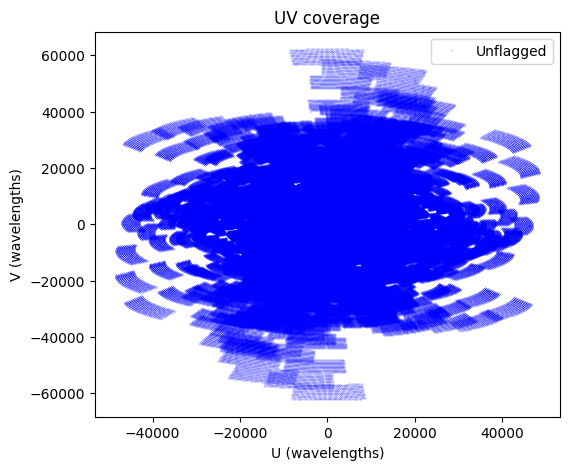

In [3]:
if vt.vis.size < 1e8:
    matplotlib.rcParams['figure.figsize'] = [6, 5]
    plot_uvcoverage([vt])

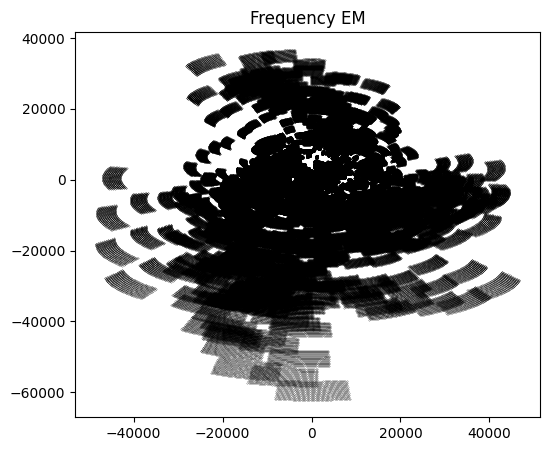

In [4]:
u = numpy.array(vt.visibility_acc.uvw_lambda[:,:,:,0]).flatten()
v = numpy.array(vt.visibility_acc.uvw_lambda[:,:,:,1]).flatten()

c = [1] * u.shape[0]

plt.title('Frequency EM')
plt.scatter(u,v,c='black',marker='.', s=0.1)
#plt.colorbar()

plt.savefig('../figures/one_sample_time_baseline.png', bbox_inches='tight')

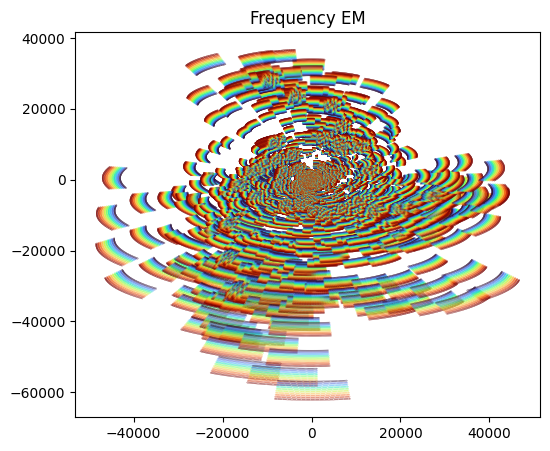

In [5]:
u = numpy.array(vt.visibility_acc.uvw_lambda[:,:,:,0]).flatten()
v = numpy.array(vt.visibility_acc.uvw_lambda[:,:,:,1]).flatten()

c = numpy.array([range(vt.vis.shape[2])] * vt.vis.shape[0] * vt.vis.shape[1])

plt.title('Frequency EM')
plt.scatter(u,v,c=c,marker='.', s=0.1, cmap=cmap)
#plt.colorbar()

plt.savefig('../figures/partition_by_freq.png', bbox_inches='tight')

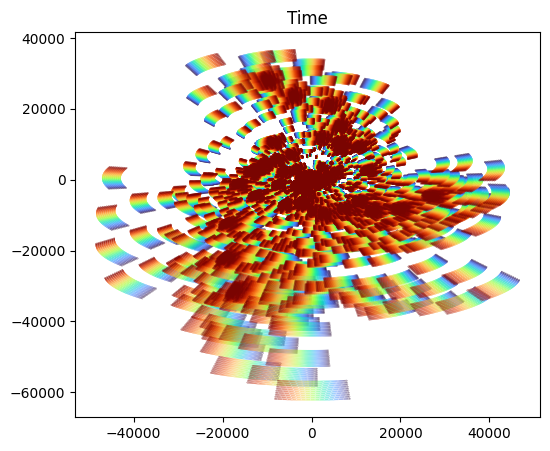

In [6]:
c = numpy.array([[i] * vt.vis.shape[1] * vt.vis.shape[2] for i in range(vt.vis.shape[0])])

plt.title('Time')
plt.scatter(u,v,c=c,marker='.', s=0.1, cmap=cmap)
#plt.colorbar()

plt.savefig('../figures/partition_by_time.png', bbox_inches='tight')

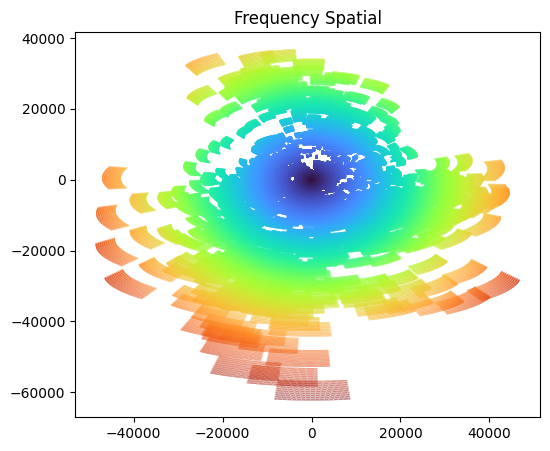

In [7]:
c = numpy.array([numpy.sqrt(u[i]**2 + v[i]**2) for i in range(u.shape[0])])

plt.title('Frequency Spatial')
plt.scatter(u,v,c=c,marker='.', s=0.1, cmap=cmap)
#plt.colorbar()

plt.savefig('../figures/partition_by_spatfreq.png', bbox_inches='tight')

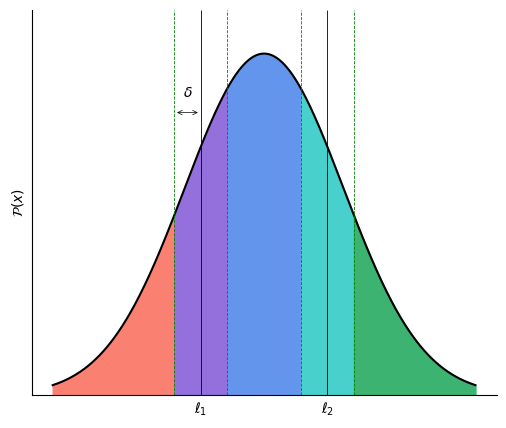

In [8]:
from scipy.stats import norm
import matplotlib.patches as patches

ells = [-1.2, 1.2]
transit_lines = [-1.7, -0.7, 0.7, 1.7]

fig, ax = plt.subplots()

x = numpy.linspace(-4, 4, 1000) 

#ax.set_xlabel('$x$', labelpad=15)
ax.set_ylabel('$\mathcal{P}(x)$')
ax.set_title('')

ax.plot(x, norm.pdf(x, loc=0, scale=1.5), color="black")
ax.fill_between(x, norm.pdf(x, loc=0, scale=1.5), where=(x < transit_lines[0]), color="salmon")
ax.fill_between(x, norm.pdf(x, loc=0, scale=1.5), where=(x < transit_lines[1]) & (x > transit_lines[0]), color="mediumpurple")
ax.fill_between(x, norm.pdf(x, loc=0, scale=1.5), where=(x < transit_lines[2]) & (x > transit_lines[1]), color="cornflowerblue")
ax.fill_between(x, norm.pdf(x, loc=0, scale=1.5), where=(x < transit_lines[3]) & (x > transit_lines[2]), color="mediumturquoise")
ax.fill_between(x, norm.pdf(x, loc=0, scale=1.5), where=(x > transit_lines[3]), color="mediumseagreen")

                                                       
ax.vlines(ells, 0, 0.3, colors='black', linewidth=0.6)
ax.vlines(transit_lines, 0, 0.3, colors='g', linestyles='dashed', linewidth=0.6)
ax.text(ells[0], -0.018, '$\ell_1$', ha='center', va='bottom')
ax.text(ells[1], -0.018, '$\ell_2$', ha='center', va='bottom')

arrow = patches.FancyArrowPatch(
    (transit_lines[0], 0.22), (ells[0], 0.22),
    arrowstyle='<->',
    mutation_scale=8,
    linewidth=0.5,
    fill=False, 
    color='black'
)
ax.add_patch(arrow)
ax.text((ells[0] + transit_lines[0])/2, 0.23, '$\delta$', ha='center', va='bottom')

# ax.text(-1.8, 0.03, '$\mathcal{A}$', ha='center', va='bottom', fontsize=30)
# ax.text(0, 0.13, '$\mathcal{B}$', ha='center', va='bottom', fontsize=30)
# ax.text(1.8, 0.03, '$\mathcal{C}$', ha='center', va='bottom', fontsize=30)

ax.set_ylim(0, 0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])
plt.savefig("../figures/partition_example.png", pad_inches=0.0, bbox_inches='tight')